# Threshold Engineering & Deep Diagnostics

| Strategy | Optimises | When to use |
|----------|-----------|-------------|
| **Max F1** | Harmonic mean of precision & recall | General-purpose balanced decision |
| **Min Cost** | Total monetary cost (cost matrix) | Business-driven trade-off |
| **Recall ≥ 90%** | Catches ≥90% of all fraud | Regulatory / compliance mandate |

**Sections 9–12** add diagnostic plots:
- Feature-wise reconstruction error (which features expose fraud)
- Anomaly score vs Amount (bias check)
- Latent space T-SNE (encoder quality)
- Visual confusion matrix (business communication)

## 0. Colab Setup

In [4]:
# ── Mount Google Drive ────────────────────────────────────────────────────────
from google.colab import drive
drive.mount("/content/drive")

import subprocess, sys
pkgs = ["optuna"]
subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + pkgs, check=True)

print("Drive mounted and packages ready.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted and packages ready.


In [5]:
import os

REPO_URL = 'https://github.com/nanokwok/Deep-Fraud-VAE.git'
REPO_NAME = 'Deep-Fraud-VAE'

if not os.path.exists(REPO_NAME):
    print(f"Cloning {REPO_NAME}...")
    !git clone {REPO_URL}
else:
    print(f"{REPO_NAME} already exists.")

repo_path = os.path.abspath(REPO_NAME)
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)

print(f"Repository path added to sys.path: {repo_path}")

Cloning Deep-Fraud-VAE...
Cloning into 'Deep-Fraud-VAE'...
remote: Enumerating objects: 264, done.
remote: Counting objects: 100% (264/264), done.
remote: Compressing objects: 100% (186/186), done.
remote: Total 264 (delta 101), reused 224 (delta 61), pack-reused 0 (from 0)
Receiving objects: 100% (264/264), 5.97 MiB | 13.15 MiB/s, done.
Resolving deltas: 100% (101/101), done.
Repository path added to sys.path: /content/Deep-Fraud-VAE


In [6]:
from pathlib import Path

DRIVE_ROOT = Path("/content/drive/MyDrive/Fraud_VAE_Project")

if str(DRIVE_ROOT) not in sys.path:
    sys.path.insert(0, str(DRIVE_ROOT))

PROC_DIR   = DRIVE_ROOT / "data" / "processed"
CKPT_PATH  = DRIVE_ROOT / "model" / "best_model.pth"
OUTPUT_DIR = DRIVE_ROOT / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Processed data : {PROC_DIR}  exists={PROC_DIR.exists()}")
print(f"Checkpoint     : {CKPT_PATH}  exists={CKPT_PATH.exists()}")
print(f"Output dir     : {OUTPUT_DIR}")
missing = [p for p in [
    PROC_DIR / "X_val.npy", PROC_DIR / "y_val.npy",
    PROC_DIR / "X_test.npy", PROC_DIR / "y_test.npy",
] if not p.exists()]
if missing:
    print("\nMISSING FILES:")
    for p in missing: print(f"  {p}")
else:
    print("\nAll required files found.")

Processed data : /content/drive/MyDrive/Fraud_VAE_Project/data/processed  exists=True
Checkpoint     : /content/drive/MyDrive/Fraud_VAE_Project/model/best_model.pth  exists=True
Output dir     : /content/drive/MyDrive/Fraud_VAE_Project/figures

All required files found.


## 1. Setup

In [7]:
import sys, json
import numpy as np
import torch
import matplotlib.pyplot as plt

from src.evaluate import (
    compute_anomaly_scores,
    compute_per_feature_errors,
    compute_latent_mu,
    plot_feature_reconstruction_error,
    plot_latent_tsne,
    plot_score_vs_amount,
    plot_confusion_matrix_heatmap,
    threshold_analysis,
    find_optimal_thresholds,
    plot_threshold_curves,
    evaluate_at_threshold,
)
from src.train import _build_feature_weights
import src.config as cfg

FEATURE_COLS = ["Time"] + [f"V{i}" for i in range(1, 29)] + ["Amount"]
AMOUNT_IDX   = FEATURE_COLS.index("Amount")   # = 29

device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps"  if torch.backends.mps.is_available() else "cpu"
)
print(f"Device      : {device}")
print(f"Checkpoint  : {CKPT_PATH}")
print(f"Output dir  : {OUTPUT_DIR}")

Device      : cpu
Checkpoint  : /content/drive/MyDrive/Fraud_VAE_Project/model/best_model.pth
Output dir  : /content/drive/MyDrive/Fraud_VAE_Project/figures


## 2. Cost Matrix

Adjust these to match your business context.

In [8]:
COST_FN = 1_000.0
COST_FP =   100.0

print(f"Cost of missing fraud (FN) : {COST_FN:>8,.0f} ฿")
print(f"Cost of blocking normal (FP): {COST_FP:>8,.0f} ฿")
print(f"FN/FP cost ratio            : {COST_FN/COST_FP:.1f}×")

Cost of missing fraud (FN) :    1,000 ฿
Cost of blocking normal (FP):      100 ฿
FN/FP cost ratio            : 10.0×


## 3. Compute Anomaly Scores

In [9]:
X_val  = np.load(PROC_DIR / "X_val.npy").astype(np.float32)
y_val  = np.load(PROC_DIR / "y_val.npy").astype(np.int32)
X_test = np.load(PROC_DIR / "X_test.npy").astype(np.float32)
y_test = np.load(PROC_DIR / "y_test.npy").astype(np.int32)

feat_w = _build_feature_weights(device)

scores_val  = compute_anomaly_scores(CKPT_PATH, X_val,  device, feature_weights=feat_w)
scores_test = compute_anomaly_scores(CKPT_PATH, X_test, device, feature_weights=feat_w)

print(f"Val   fraud_rate={y_val.mean()*100:.2f}%  "
      f"score_normal={scores_val[y_val==0].mean():.4f}  "
      f"score_fraud={scores_val[y_val==1].mean():.4f}")
print(f"Test  fraud_rate={y_test.mean()*100:.2f}%  "
      f"score_normal={scores_test[y_test==0].mean():.4f}  "
      f"score_fraud={scores_test[y_test==1].mean():.4f}")

sep_val  = scores_val[y_val==1].mean()  / (scores_val[y_val==0].mean()  + 1e-9)
sep_test = scores_test[y_test==1].mean()/ (scores_test[y_test==0].mean()+ 1e-9)
print(f"Separation  val={sep_val:.2f}×  test={sep_test:.2f}×")

Val   fraud_rate=0.57%  score_normal=0.7329  score_fraud=13.0631
Test  fraud_rate=0.57%  score_normal=0.7347  score_fraud=13.2858
Separation  val=17.82×  test=18.08×


## 4. Threshold Sweep (Validation Set)

Thresholds are selected on the **val set only**.  
Test set is used exclusively for final reporting in Section 6.

In [10]:
rows_val = threshold_analysis(
    scores_val, y_val, n_points=500, cost_fn=COST_FN, cost_fp=COST_FP
)
opt_val = find_optimal_thresholds(rows_val, min_recall=0.90)

print(f"Max-F1  threshold = {opt_val['max_f1']:.4f}   F1 = {opt_val['max_f1_score']:.4f}")
print(f"MinCost threshold = {opt_val['min_cost']:.4f}   cost = {opt_val['min_cost_value']:,.0f} ฿")
print(f"R≥90%%  threshold = {opt_val['recall90']:.4f}")

Max-F1  threshold = 8.6957   F1 = 0.7024
MinCost threshold = 6.2518   cost = 75,300 ฿
R≥90%%  threshold = 0.9198


## 5. Threshold Curves

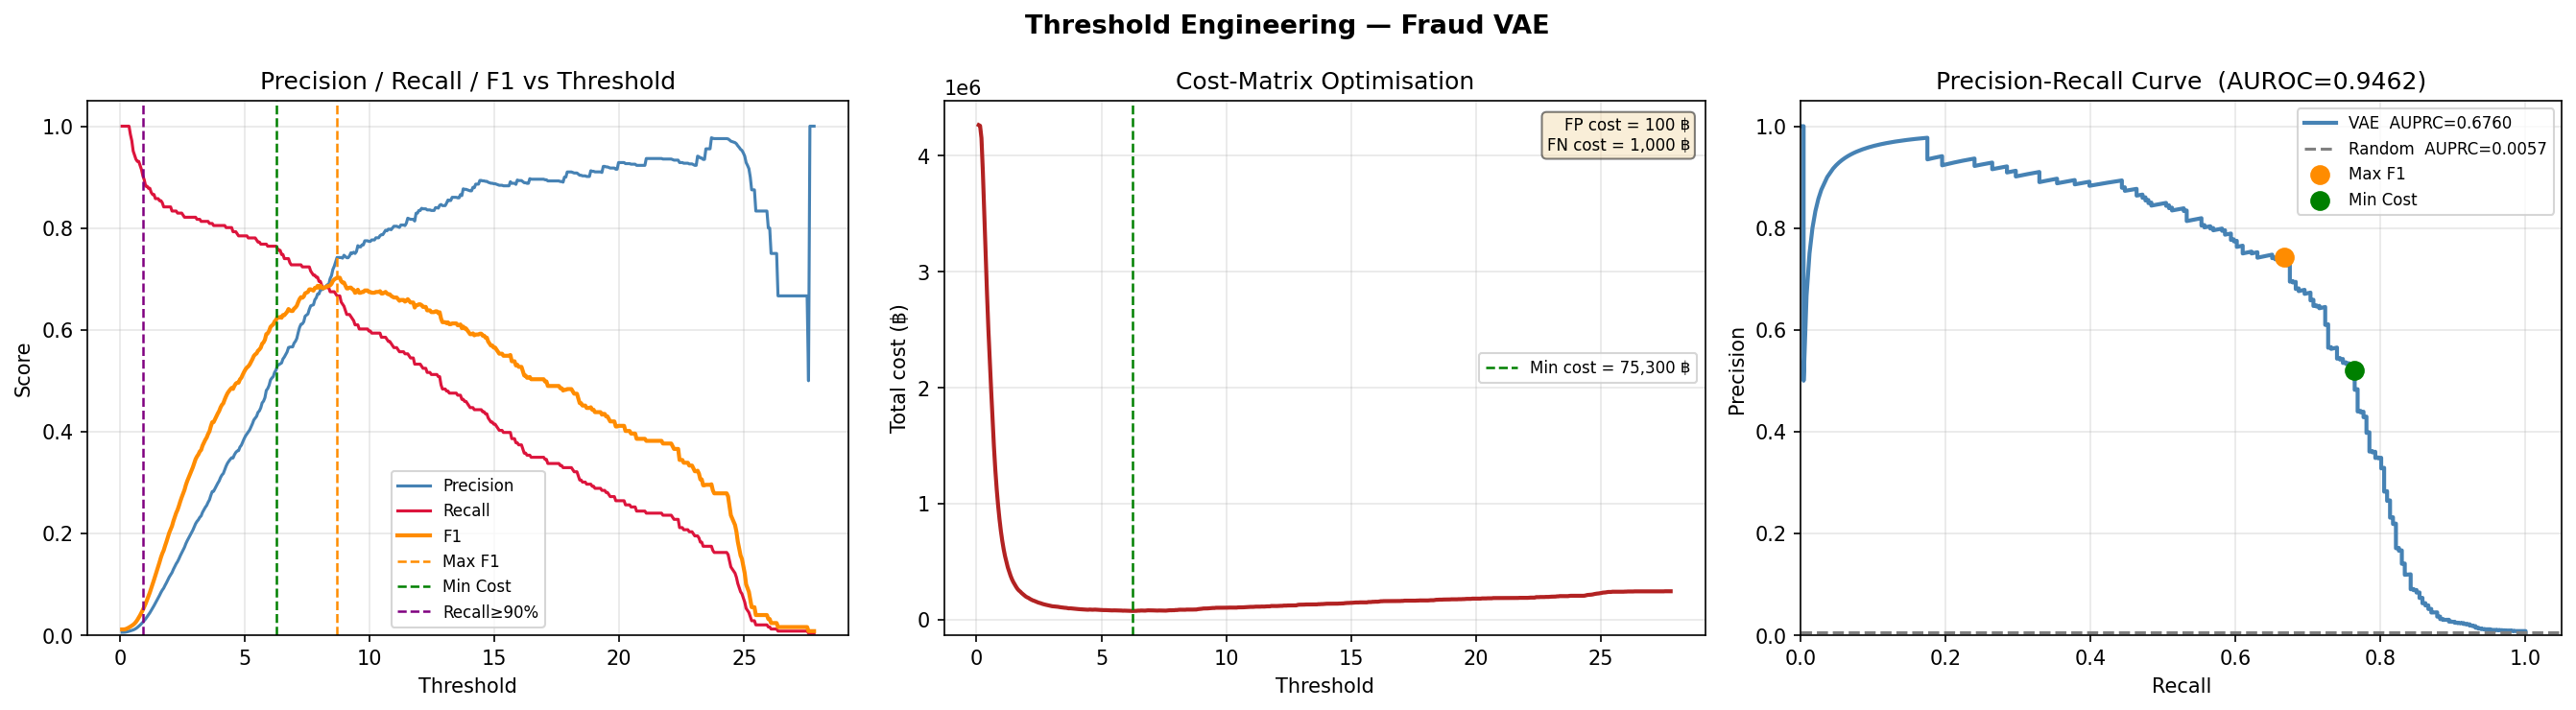

In [11]:
from IPython.display import Image

fig_path = OUTPUT_DIR / "threshold_curves_val.png"
plot_threshold_curves(
    rows_val, opt_val, scores_val, y_val, fig_path,
    cost_fn=COST_FN, cost_fp=COST_FP,
)
Image(str(fig_path), width=1000)

## 6. Detailed Reports at Each Optimal Threshold

Thresholds found on val are now applied to the **held-out test set**.

In [12]:
thresholds_to_report = {
    "Max F1"       : opt_val["max_f1"],
    "Min Cost"     : opt_val["min_cost"],
    "Recall >= 90%": opt_val["recall90"],
}

test_results = {}
for name, t in thresholds_to_report.items():
    if t < 0:
        print(f"{name}: no threshold achieves recall >= 90% — skipped")
        continue
    test_results[name] = evaluate_at_threshold(
        scores_test, y_test, t,
        cost_fn=COST_FN, cost_fp=COST_FP,
        label=f"{name} (test)",
    )


──────────────────────────────────────────────────
  Max F1 (test)  |  threshold = 8.6957
──────────────────────────────────────────────────
  Confusion matrix:
    TP=   166   FP=    68
    FN=    80   TN=42,580
  Precision : 0.7094
  Recall    : 0.6748   (fraud caught rate)
  F1-score  : 0.6917
  FPR       : 0.0016   (normal customers wrongly blocked)
  Total cost:       86,800 ฿
    FP cost :        6,800 ฿  (68 customers blocked)
    FN cost :       80,000 ฿  (80 frauds missed)
──────────────────────────────────────────────────

──────────────────────────────────────────────────
  Min Cost (test)  |  threshold = 6.2518
──────────────────────────────────────────────────
  Confusion matrix:
    TP=   197   FP=   164
    FN=    49   TN=42,484
  Precision : 0.5457
  Recall    : 0.8008   (fraud caught rate)
  F1-score  : 0.6491
  FPR       : 0.0038   (normal customers wrongly blocked)
  Total cost:       65,400 ฿
    FP cost :       16,400 ฿  (164 customers blocked)
    FN cost :      

## 7. Score Distribution — Val Set

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

clip = float(np.percentile(scores_val, 99))
bins = np.linspace(0, clip, 80)

ax = axes[0]
ax.hist(scores_val[y_val==0].clip(max=clip), bins=bins, alpha=0.6,
        density=True, color="steelblue", label=f"Normal  n={int((y_val==0).sum()):,}")
ax.hist(scores_val[y_val==1].clip(max=clip), bins=bins, alpha=0.6,
        density=True, color="crimson",   label=f"Fraud   n={int((y_val==1).sum()):,}")
for name, t, color in [
    ("Max F1",   opt_val["max_f1"],   "darkorange"),
    ("Min Cost", opt_val["min_cost"], "green"),
]:
    ax.axvline(t, color=color, linestyle="--", linewidth=1.5, label=name)
ax.set_xlabel("Anomaly score"); ax.set_ylabel("Density")
ax.set_title("Score Distribution — Val Set")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
for label, s, c in [("Normal", scores_val[y_val==0], "steelblue"),
                    ("Fraud",  scores_val[y_val==1], "crimson")]:
    sorted_s = np.sort(s)
    cdf = np.arange(1, len(sorted_s)+1) / len(sorted_s)
    ax.plot(sorted_s, cdf, color=c, label=label)
for name, t, color in [
    ("Max F1",   opt_val["max_f1"],   "darkorange"),
    ("Min Cost", opt_val["min_cost"], "green"),
]:
    ax.axvline(t, color=color, linestyle="--", linewidth=1.5, label=name)
ax.set_xlabel("Anomaly score"); ax.set_ylabel("Cumulative fraction")
ax.set_title("CDF — Normal vs Fraud")
ax.set_xlim(0, clip); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Save Thresholds

In [14]:
output = {
    "cost_fn"    : COST_FN,
    "cost_fp"    : COST_FP,
    "thresholds" : {
        "max_f1"  : opt_val["max_f1"],
        "min_cost": opt_val["min_cost"],
        "recall90": opt_val["recall90"],
    },
    "test_reports": test_results,
}

out_path = OUTPUT_DIR / "thresholds.json"
with open(out_path, "w") as f:
    json.dump(output, f, indent=2)

print(f"Saved → {out_path}")
print(json.dumps(output["thresholds"], indent=2))

Saved → /content/drive/MyDrive/Fraud_VAE_Project/figures/thresholds.json
{
  "max_f1": 8.695663452148438,
  "min_cost": 6.251810550689697,
  "recall90": 0.9197659492492676
}


---
## 9. Feature-wise Reconstruction Error

In [15]:
pfe_test = compute_per_feature_errors(CKPT_PATH, X_test, device, feature_weights=feat_w)
print(f"Per-feature error shape: {pfe_test.shape}  (samples × features)")

mean_normal = pfe_test[y_test == 0].mean(axis=0)
mean_fraud  = pfe_test[y_test == 1].mean(axis=0)
delta       = mean_fraud - mean_normal
order       = np.argsort(delta)[::-1]

print("\nTop-10 features by fraud−normal reconstruction error gap:")
print(f"{'Feature':<10} {'Normal MSE':>12} {'Fraud MSE':>12} {'Gap':>10}")
print("-" * 48)
for i in order[:10]:
    print(f"{FEATURE_COLS[i]:<10} {mean_normal[i]:>12.5f} {mean_fraud[i]:>12.5f} {delta[i]:>10.5f}")

Per-feature error shape: (42894, 30)  (samples × features)

Top-10 features by fraud−normal reconstruction error gap:
Feature      Normal MSE    Fraud MSE        Gap
------------------------------------------------
V17             0.92193     66.42537   65.50344
V12             0.88833     40.93927   40.05095
V14             0.49509     36.45187   35.95678
V10             0.82990     34.77771   33.94781
V16             1.15519     34.01618   32.86099
V11             1.08286     30.81088   29.72802
V7              0.94872     25.46280   24.51408
V3              0.57147     22.36296   21.79149
V4              0.86102     17.60140   16.74039
V1              0.72795     12.75596   12.02801


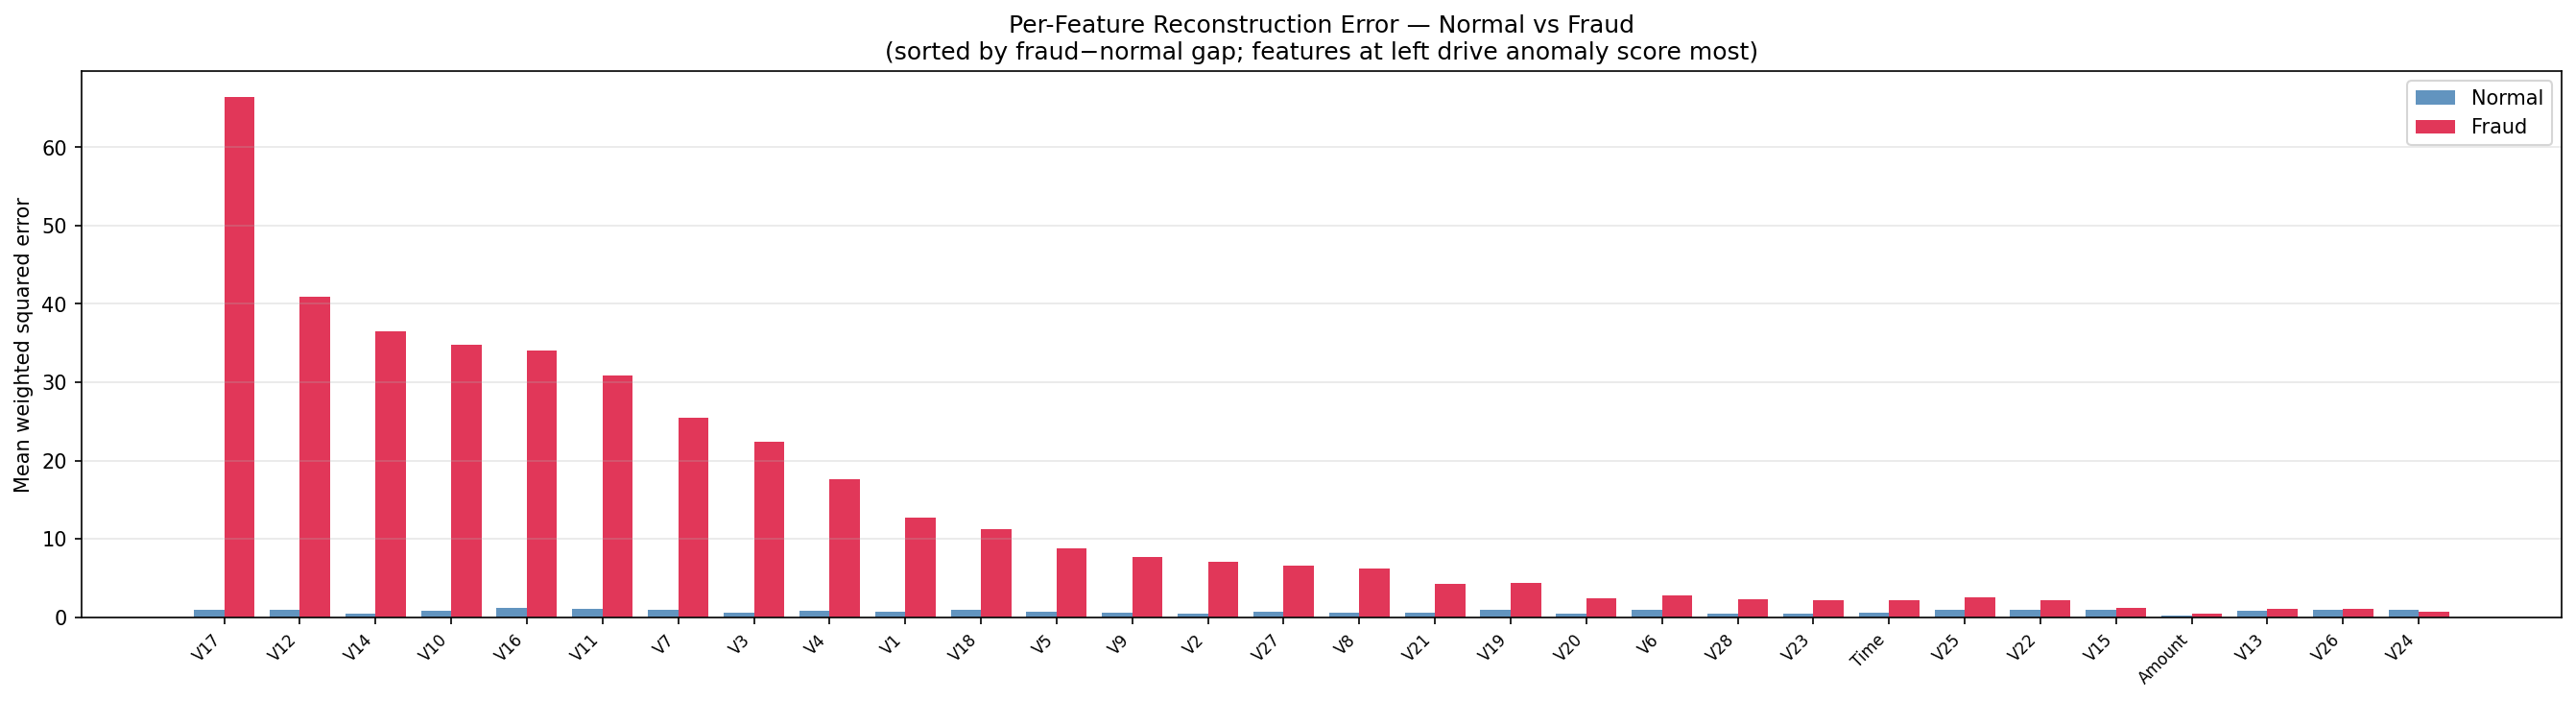

In [16]:
feat_err_path = OUTPUT_DIR / "feature_reconstruction_error.png"
plot_feature_reconstruction_error(pfe_test, y_test, FEATURE_COLS, feat_err_path)
Image(str(feat_err_path), width=1100)

## 10. Anomaly Score vs Transaction Amount

In [17]:
amount_test  = X_test[:, AMOUNT_IDX]
scatter_path = OUTPUT_DIR / "score_vs_amount.png"
plot_score_vs_amount(
    scores_test, y_test, amount_test, scatter_path,
    threshold=opt_val["max_f1"],
    threshold_label="Max F1",
)
Image(str(scatter_path), width=900)

# Bias check: do low-amount frauds score lower?
fraud_mask = y_test == 1
med_amount = np.median(amount_test[fraud_mask])
lo = scores_test[fraud_mask & (amount_test <= med_amount)]
hi = scores_test[fraud_mask & (amount_test >  med_amount)]
print(f"Fraud score — low-amount  median: {np.median(lo):.4f}")
print(f"Fraud score — high-amount median: {np.median(hi):.4f}")
print("(low ≈ high → no amount bias; low << high → bias exists)")

Fraud score — low-amount  median: 12.1502
Fraud score — high-amount median: 14.2409
(low ≈ high → no amount bias; low << high → bias exists)


## 11. Latent Space T-SNE

Latent μ shape: (85787, 4)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


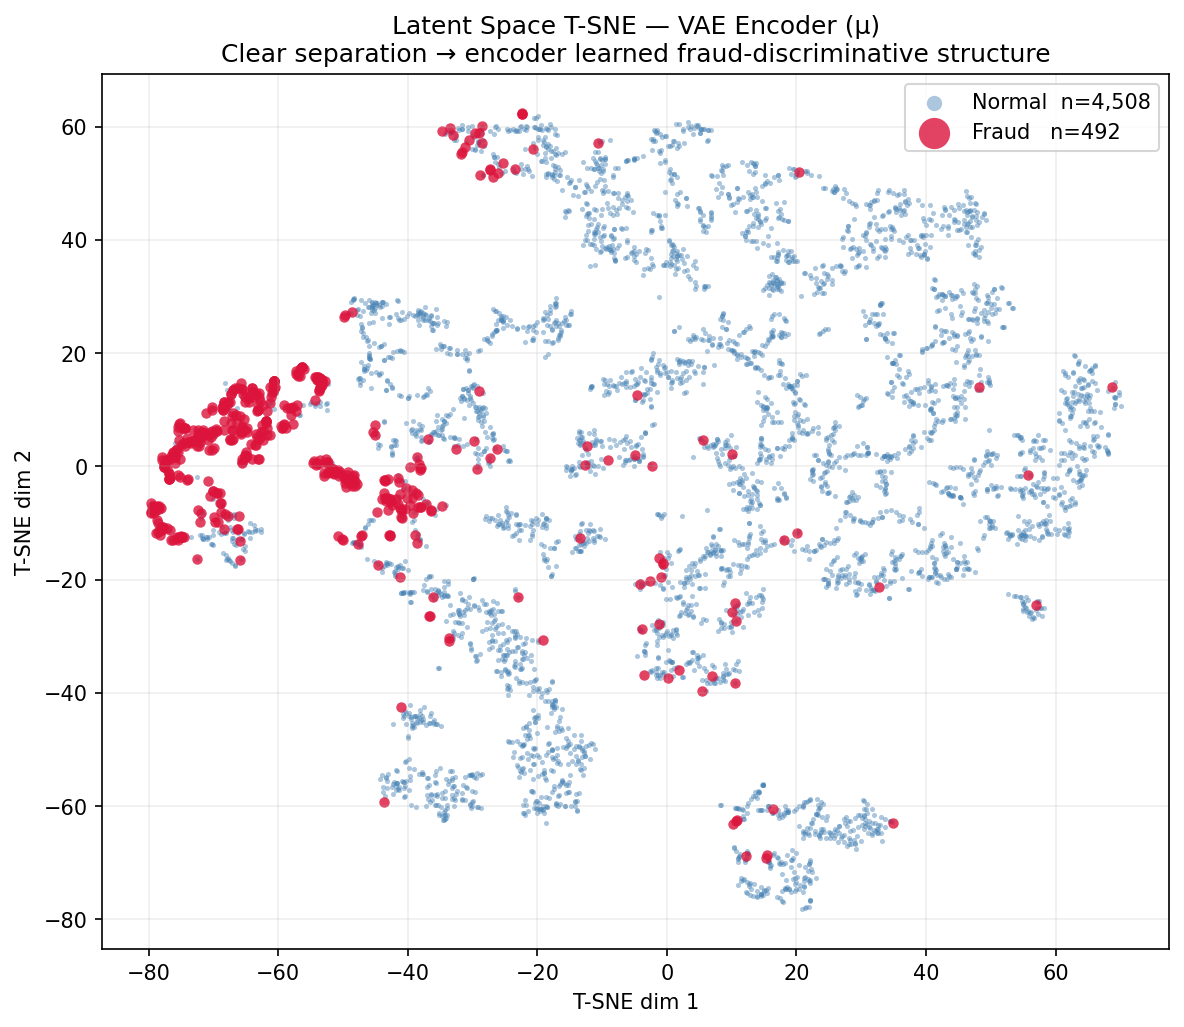

In [18]:
X_all = np.concatenate([X_val,  X_test],  axis=0)
y_all = np.concatenate([y_val,  y_test],  axis=0)

mu_all    = compute_latent_mu(CKPT_PATH, X_all, device)
tsne_path = OUTPUT_DIR / "latent_tsne.png"
print(f"Latent μ shape: {mu_all.shape}")

plot_latent_tsne(mu_all, y_all, tsne_path, n_samples=5_000, random_state=42)
Image(str(tsne_path), width=750)

## 12. Confusion Matrix Heatmap


──────────────────────────────────────── Max F1 ────────────────────────────────────────


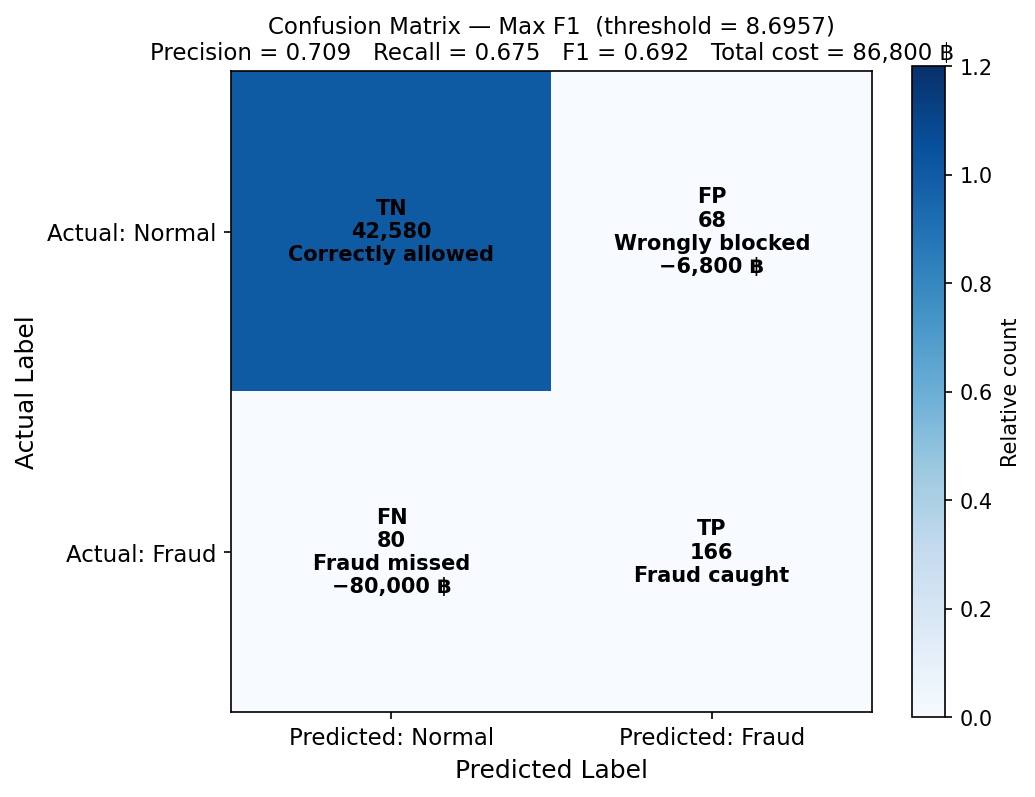


──────────────────────────────────────── Min Cost ────────────────────────────────────────


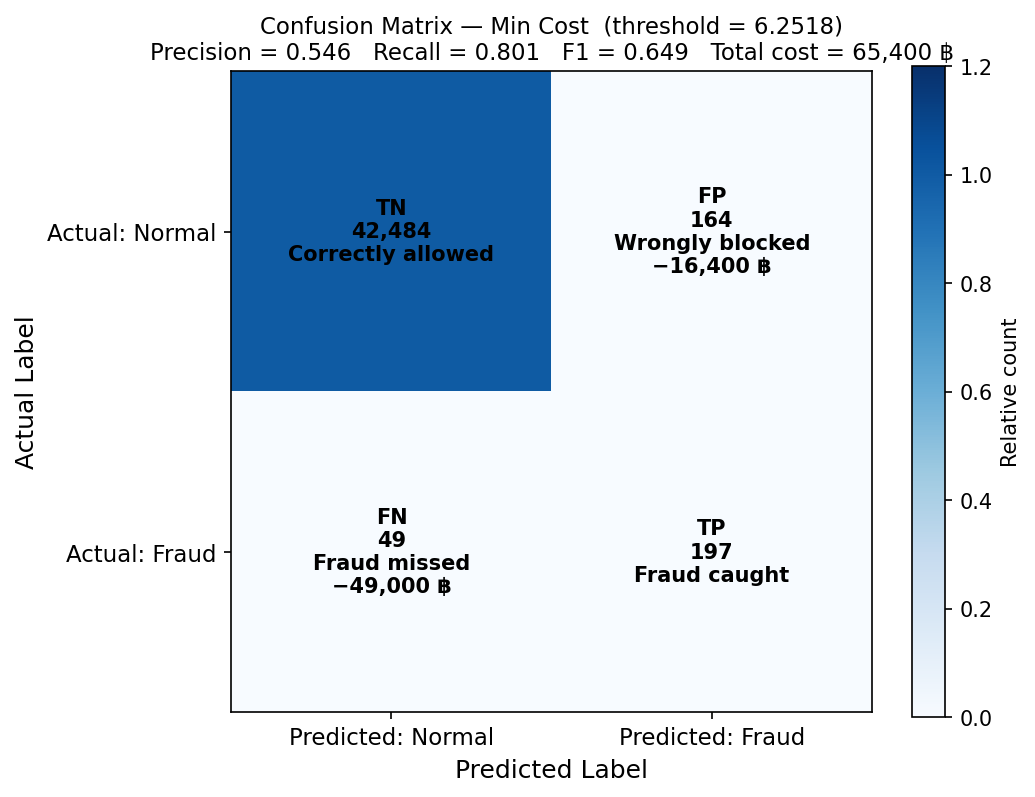


──────────────────────────────────────── Recall≥90%% ────────────────────────────────────────


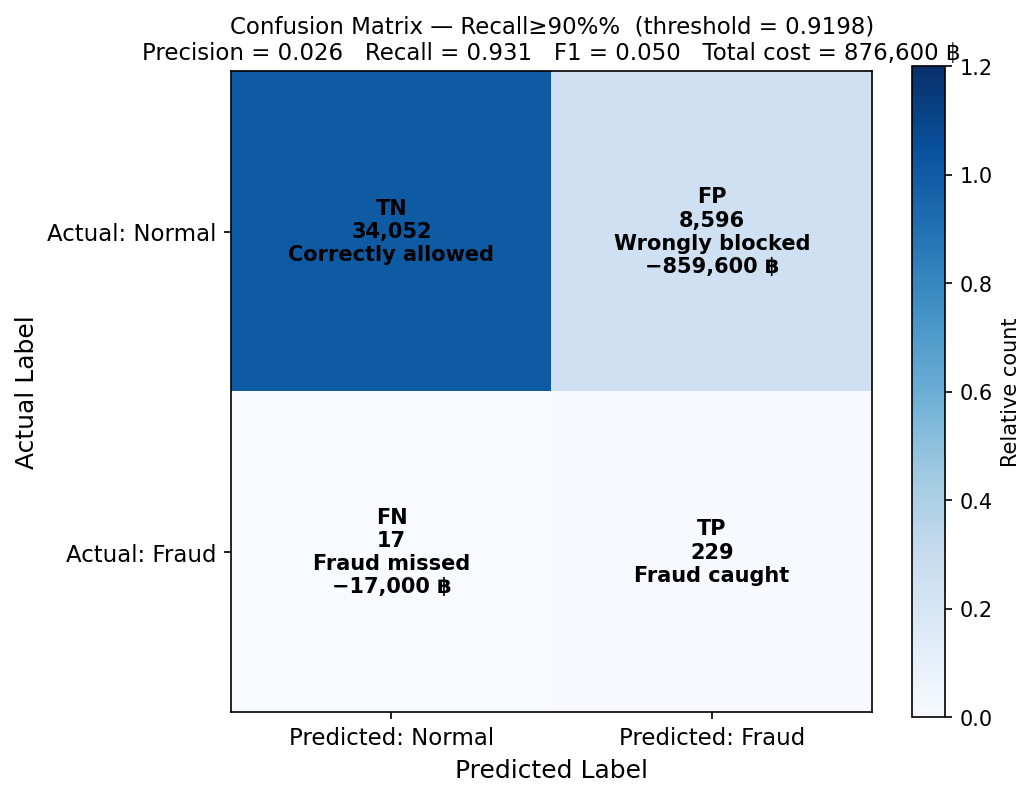

In [19]:
from IPython.display import display, Image as Img

cm_configs = [
    ("Max F1",      opt_val["max_f1"]),
    ("Min Cost",    opt_val["min_cost"]),
    ("Recall≥90%%", opt_val["recall90"]),
]

for label, t in cm_configs:
    if t < 0:
        print(f"{label}: skipped (no threshold achieves recall ≥ 90%)")
        continue
    safe = label.replace(">=", "ge").replace("%%", "pct").replace(" ", "_").lower()
    cm_path = OUTPUT_DIR / f"confusion_matrix_{safe}.png"
    plot_confusion_matrix_heatmap(
        scores_test, y_test, t, cm_path,
        label=label, cost_fn=COST_FN, cost_fp=COST_FP,
    )
    print(f"\n{'─'*40} {label} {'─'*40}")
    display(Img(str(cm_path), width=600))